In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.stats import ttest_ind
import squarify
import matplotlib
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from mlxtend.frequent_patterns import fpgrowth
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# import dataset & Encode

In [2]:
DF = pd.read_csv(r'GeneratedOrderData_17000x2.csv')

In [3]:
DF.shape

(34000, 14)

In [4]:
DF.head()

,OrderID,ProductName,Quantity,InvoiceDate,UnitPrice,TotalCost,Country,DiscountApplied,OrderPriority,Region,Segment,ExpeditedShipping,PaymentMethod,CustomerOrderSatisfaction
0,31922,BOWL SUKI,920,9/1/22 17:28,42.85,39422.00,United States,Yes,High,Northeast,Consumer,Yes,Paypal,Very Satisfied
1,12447,GARLAND SCANDINAVIAN,920,9/1/22 17:28,42.85,39422.00,United States,Yes,High,Northeast,Consumer,Yes,Paypal,Very Satisfied
2,32657,FLOWER DOILIES,418,9/1/22 20:10,13.02,5442.36,United States,No,Medium,Northeast,Consumer,Yes,Credit Card,Very Satisfied
3,85543,AND TAILS CARD,418,9/1/22 20:10,13.02,5442.36,United States,No,Medium,Northeast,Consumer,Yes,Credit Card,Very Satisfied
4,92783,KEEP CALM AND,507,9/1/22 21:59,47.02,23839.14,United States,No,High,Northeast,Consumer,Yes,Paypal,Prefer not to answer


In [5]:
## examine encoding possibilities

In [6]:
DF['OrderPriority'].unique()

array(['High', 'Medium'], dtype=object)

In [7]:
DF['PaymentMethod'].unique()

array(['Paypal', 'Credit Card'], dtype=object)

In [8]:
DF['ExpeditedShipping'].unique()

array(['Yes', 'No'], dtype=object)

In [9]:
DF['CustomerOrderSatisfaction'].unique()

array(['Very Satisfied', 'Prefer not to answer', 'Dissatisfied',
       'Satisfied', 'Very Dissatisfied'], dtype=object)

In [10]:
DF['DiscountApplied'].unique()

array(['Yes', 'No'], dtype=object)

In [11]:
DF['Segment'].unique()

array(['Consumer', 'Corporate'], dtype=object)

In [12]:
#encode ordinal values with ordinal encoding

In [13]:
OrderPriority = {'Medium': 1, 'High': 2}
DF['OrderPriority_Encoded'] = DF['OrderPriority'].map(OrderPriority)

In [14]:
PaymentMethod = {'Paypal': 1, 'Credit Card': 2}
DF['PaymentMethod_Encoded'] = DF['OrderPriority'].map(OrderPriority)

In [15]:
CustomerSatisfaction_map = {
    'Very Dissatisfied': 1,
    'Dissatisfied': 2,
    'Satisfied': 3,
    'Very Satisfied': 4,
    'Prefer not to answer': -99
}
DF['CustomerSatisfaction_encoded'] = DF['CustomerOrderSatisfaction'].map(CustomerSatisfaction_map)

In [16]:
#use one hot encoding for categorical variables
DF = pd.get_dummies(DF, columns=['Segment'], prefix='Segment')
DF = pd.get_dummies(DF, columns=['ExpeditedShipping'], prefix='ExpeditedShipping')
DF = pd.get_dummies(DF, columns=['DiscountApplied'], prefix='DiscountApplied')

In [17]:
DF.columns

Index(['OrderID', 'ProductName', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'TotalCost', 'Country', 'OrderPriority', 'Region', 'PaymentMethod',
       'CustomerOrderSatisfaction', 'OrderPriority_Encoded',
       'PaymentMethod_Encoded', 'CustomerSatisfaction_encoded',
       'Segment_Consumer', 'Segment_Corporate', 'ExpeditedShipping_No',
       'ExpeditedShipping_Yes', 'DiscountApplied_No', 'DiscountApplied_Yes'],
      dtype='object')

In [18]:
DF.head()

,OrderID,ProductName,Quantity,InvoiceDate,UnitPrice,TotalCost,Country,OrderPriority,Region,PaymentMethod,CustomerOrderSatisfaction,OrderPriority_Encoded,PaymentMethod_Encoded,CustomerSatisfaction_encoded,Segment_Consumer,Segment_Corporate,ExpeditedShipping_No,ExpeditedShipping_Yes,DiscountApplied_No,DiscountApplied_Yes
0,31922,BOWL SUKI,920,9/1/22 17:28,42.85,39422.00,United States,High,Northeast,Paypal,Very Satisfied,2,2,4,1,0,0,1,0,1
1,12447,GARLAND SCANDINAVIAN,920,9/1/22 17:28,42.85,39422.00,United States,High,Northeast,Paypal,Very Satisfied,2,2,4,1,0,0,1,0,1
2,32657,FLOWER DOILIES,418,9/1/22 20:10,13.02,5442.36,United States,Medium,Northeast,Credit Card,Very Satisfied,1,1,4,1,0,0,1,1,0
3,85543,AND TAILS CARD,418,9/1/22 20:10,13.02,5442.36,United States,Medium,Northeast,Credit Card,Very Satisfied,1,1,4,1,0,0,1,1,0
4,92783,KEEP CALM AND,507,9/1/22 21:59,47.02,23839.14,United States,High,Northeast,Paypal,Prefer not to answer,2,2,-99,1,0,0,1,1,0


In [19]:
#replace the original columns with their new, encoded columns
DF2 = DF[['OrderID', 'ProductName', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'TotalCost', 'Country', 'DiscountApplied_No', 'DiscountApplied_Yes', 'OrderPriority_Encoded', 'Region',
       'PaymentMethod_Encoded', 'CustomerSatisfaction_encoded', 'Segment_Consumer', 'Segment_Corporate',
       'ExpeditedShipping_No', 'ExpeditedShipping_Yes']]

In [20]:
DF2.to_csv("OrderDataset_Encoded.csv", index=False)

# Market Basket Analysis

In [21]:
#first isolate product name and pivot so that there is one column for each product in an order - this is the format
#transaction_encoder can easily read to transactionalize
DF_T = DF[['OrderID','ProductName']].copy()
DF_T['count'] = DF_T.groupby(['OrderID']).cumcount()
DF2F = DF_T.pivot(index=['OrderID'],columns='count')
DF2F.columns = [f'{a} {b+1}' if b > 0 else a for a, b in DF2F.columns]
DF2F3 = DF2F.reset_index().rename_axis(None,axis=1)

In [22]:
DF2F3.head()

,OrderID,ProductName,ProductName 2,ProductName 3,ProductName 4,ProductName 5,ProductName 6,ProductName 7
0,10124,WATER BOTTLE,LUNCH BOX WRAP,TOADSTOOL BEDSIDE LIGHT,CLOSED METAL SIGN,PARTY BALLOONS,LUNCH BAG,ALPHABET LUNCH
1,10151,POLKA DOT,INGRID EGG CUP,FAIRY CAKES,SET RED,CAKE CASES SET,PINK GIN TONIC,CAKE CASES
2,10226,CAKE CASES VINTAGE,CAKE CASES,FAIRY CAKES,AND CROSSBS GARLAND,SET POSIES,CAKE CASES SET,TRAVEL CARD WALLET
3,10265,BAG DOLLY,VINTAGE GLASS,MAGNETS PACK OF,PATTERNS LUNCH,COLOUR TLIGHT HOLDER,ORIGAMI VANILLA INCENSECANDLE,CHALK STICKS PACK
4,10278,GINGHAM DOILY,LARGE HANGING IVORY,VINTAGE HEARTS,PAPER DOILIES,BAG VINTAGE,FLOWER DOILIES,DOILY THANK YOU


In [23]:
DF2F3.shape

(5000, 8)

In [25]:
trans = []
for i in range(0, 5000):
    trans.append([
        str(DF2F3.values[i, j])
        for j in range(1, 8)
        if pd.notna(DF2F3.values[i, j])
    ])

trans = np.array(trans, dtype=object)

print(trans.shape)

(5000,)


In [26]:
t=TransactionEncoder()
DF2F3=t.fit_transform(trans)
DF_T2=pd.DataFrame(DF2F3,columns=t.columns_,dtype=int)

DF_T2.shape

(5000, 1231)

In [27]:
DF_T2.head()

,A PRETTY THANK,ACAPULCO MAT,ACAPULCO MAT GREEN,ACAPULCO MAT PINK,ACAPULCO MAT RED,ADVENT CALENDAR RED,AIRLINE BAG,"AIRLINE LOUNGE,METAL",AIRMAIL DOORMAT I,ALL GLASS CANDLESTICK,...,YELLOW BABUSHKA,YELLOW BABUSHKA NOTEBOOK,YOUR OWN,YOUR OWN CANVAS,YOUR OWN FLOWERPOWER,ZINC HERB,ZINC METAL HEART,ZINC TLIGHT HOLDER,ZINC WICKER,g SWIRLY
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
DF_T2.to_csv("transactionalized_dataset.csv", index=False)

# Apiori Algorithm

<Figure size 1200x600 with 0 Axes>

<BarContainer object of 63 artists>

Text(0.5, 0, 'Item Frequency (count)')

Text(0, 0.5, 'Number of Items')

Text(0.5, 1.0, 'Distribution of Item Frequencies')

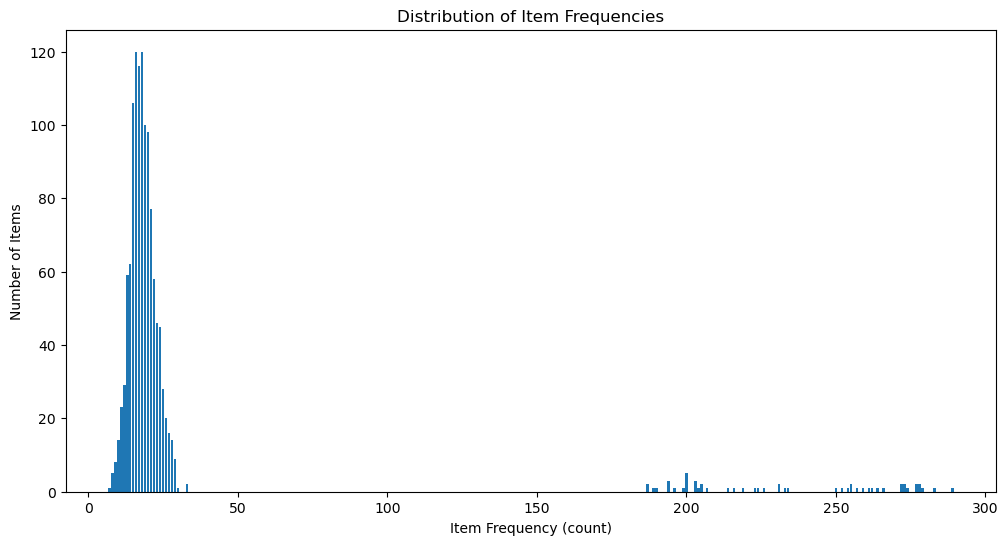

In [29]:
counts = DF_T2.sum(axis=0)
freq_counts = counts.value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.bar(freq_counts.index, freq_counts.values)
plt.xlabel("Item Frequency (count)")
plt.ylabel("Number of Items")
plt.title("Distribution of Item Frequencies")
plt.show()

In [34]:
(DF_T2.sum(axis=0) > 250).sum()

22

In [31]:
len(DF_T2)

5000

In [35]:
#get frequency counts
counts = DF_T2.sum(axis=0).sort_values(ascending=False)
#define how many top items
N = 250
#get frequency of the 13th most frequent item specifically 
min_count = counts.iloc[N-1]
# calculate minimum support by dividing 33rd most frequent item transaction frequency by total number of transactions
min_support = min_count / len(DF_T2)
min_support

0.0044

In [45]:
freq_items=apriori(DF_T2,min_support=0.03,use_colnames=True)
freq_items

,support,itemsets
0,0.0546,(ALPHABET LUNCH)
1,0.0448,(CAKE CASES)
2,0.0446,(CAKE CASES SET)
3,0.0462,(CAKE CASES VINTAGE)
4,0.0566,(CALM HOT WATER)
...,...,...
113,0.0366,"(YELLOW BABUSHKA, RED BABUSHKA, YELLOW BABUSHK..."
114,0.0334,"(WATER BOTTLE, LUNCH BOX WRAP, LUNCH BAG, ALPH..."
115,0.0318,"(HOT WATER BOTTLE, HEART HOT WATER, CALM HOT W..."
116,0.0320,"(COFFEE MUG, MUG WARMER PINK, OFFICE MUG, MUG ..."


In [46]:
res=association_rules(freq_items,metric="lift",min_threshold=1)

In [47]:
res.sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
127,"(DRAWING SLATE BUNNIES, DRAWING SLATE DINOSAUR)",(DRAWING SLATE),0.0444,0.0544,0.0388,0.873874,16.063858,1.0,0.036385,7.497257,0.981319,0.646667,0.866618,0.793555
140,"(DRAWING SLATE DINOSAUR, MAGIC DRAWING SLATE)",(DRAWING SLATE),0.0444,0.0544,0.0388,0.873874,16.063858,1.0,0.036385,7.497257,0.981319,0.646667,0.866618,0.793555
52,(WATER BOTTLE),(LUNCH BOX WRAP),0.0554,0.0578,0.0484,0.873646,15.114986,1.0,0.045198,7.456840,0.988609,0.746914,0.865895,0.855508
115,"(COFFEE MUG, OFFICE MUG)",(MUG WARMER PINK),0.0470,0.0556,0.0410,0.872340,15.689576,1.0,0.038387,7.397800,0.982438,0.665584,0.864825,0.804875
181,"(WATER BOTTLE, LUNCH BAG)",(LUNCH BOX WRAP),0.0482,0.0578,0.0420,0.871369,15.075593,1.0,0.039214,7.324845,0.980949,0.656250,0.863478,0.799006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,(LUNCH BOX WRAP),"(WATER BOTTLE, LUNCH BAG, ALPHABET LUNCH)",0.0578,0.0396,0.0334,0.577855,14.592290,1.0,0.031111,2.275046,0.988612,0.521875,0.560448,0.710645
254,(COFFEE MUG),"(MUG WARMER PINK, OFFICE MUG, MUG WARMER POLKA...",0.0554,0.0382,0.0320,0.577617,15.120872,1.0,0.029884,2.277082,0.988637,0.519481,0.560841,0.707657
255,(MUG WARMER PINK),"(COFFEE MUG, OFFICE MUG, MUG WARMER POLKADOT)",0.0556,0.0380,0.0320,0.575540,15.145778,1.0,0.029887,2.266407,0.988961,0.519481,0.558773,0.708822
243,(GREY HEART HOT),"(HOT WATER BOTTLE, HEART HOT WATER, CALM HOT W...",0.0556,0.0380,0.0318,0.571942,15.051117,1.0,0.029687,2.247361,0.988522,0.514563,0.555034,0.704392


In [48]:
res['antecedents'].unique()

array([frozenset({'LUNCH BAG'}), frozenset({'ALPHABET LUNCH'}),
       frozenset({'LUNCH BOX WRAP'}), frozenset({'WATER BOTTLE'}),
       frozenset({'CALM HOT WATER'}), frozenset({'GREY HEART HOT'}),
       frozenset({'HEART HOT WATER'}), frozenset({'HOT WATER BOTTLE'}),
       frozenset({'COFFEE MUG'}), frozenset({'MUG WARMER PINK'}),
       frozenset({'MUG WARMER POLKADOT'}), frozenset({'OFFICE MUG'}),
       frozenset({'DRAWING SLATE BUNNIES'}), frozenset({'DRAWING SLATE'}),
       frozenset({'DRAWING SLATE DINOSAUR'}),
       frozenset({'MAGIC DRAWING SLATE'}), frozenset({'JUMBO BAG OWLS'}),
       frozenset({'JUMBO BAG BAROQUE'}), frozenset({'JUMBO BAG RED'}),
       frozenset({'JUMBO SHOPPER'}), frozenset({'PURSE BABUSHKA PINK'}),
       frozenset({'RED BABUSHKA'}), frozenset({'YELLOW BABUSHKA'}),
       frozenset({'YELLOW BABUSHKA NOTEBOOK'}),
       frozenset({'LUNCH BOX WRAP', 'LUNCH BAG'}),
       frozenset({'LUNCH BOX WRAP', 'ALPHABET LUNCH'}),
       frozenset({'LUNCH BAG',

In [49]:
res['consequents'].unique()

array([frozenset({'ALPHABET LUNCH'}), frozenset({'LUNCH BAG'}),
       frozenset({'LUNCH BOX WRAP'}), frozenset({'WATER BOTTLE'}),
       frozenset({'GREY HEART HOT'}), frozenset({'CALM HOT WATER'}),
       frozenset({'HEART HOT WATER'}), frozenset({'HOT WATER BOTTLE'}),
       frozenset({'MUG WARMER PINK'}), frozenset({'COFFEE MUG'}),
       frozenset({'MUG WARMER POLKADOT'}), frozenset({'OFFICE MUG'}),
       frozenset({'DRAWING SLATE'}), frozenset({'DRAWING SLATE BUNNIES'}),
       frozenset({'DRAWING SLATE DINOSAUR'}),
       frozenset({'MAGIC DRAWING SLATE'}),
       frozenset({'JUMBO BAG BAROQUE'}), frozenset({'JUMBO BAG OWLS'}),
       frozenset({'JUMBO BAG RED'}), frozenset({'JUMBO SHOPPER'}),
       frozenset({'RED BABUSHKA'}), frozenset({'PURSE BABUSHKA PINK'}),
       frozenset({'YELLOW BABUSHKA'}),
       frozenset({'YELLOW BABUSHKA NOTEBOOK'}),
       frozenset({'LUNCH BAG', 'ALPHABET LUNCH'}),
       frozenset({'LUNCH BOX WRAP', 'ALPHABET LUNCH'}),
       frozenset({'LUNC

In [50]:
res.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(LUNCH BAG),(ALPHABET LUNCH),0.0558,0.0546,0.0460,0.824373,15.098402,1.0,0.042953,5.382992,0.988951,0.714286,0.814230,0.833432
1,(ALPHABET LUNCH),(LUNCH BAG),0.0546,0.0558,0.0460,0.842491,15.098402,1.0,0.042953,5.994572,0.987696,0.714286,0.833182,0.833432
2,(LUNCH BOX WRAP),(ALPHABET LUNCH),0.0578,0.0546,0.0462,0.799308,14.639340,1.0,0.043044,4.710700,0.988846,0.697885,0.787717,0.822731
3,(ALPHABET LUNCH),(LUNCH BOX WRAP),0.0546,0.0578,0.0462,0.846154,14.639340,1.0,0.043044,6.124300,0.985499,0.697885,0.836716,0.822731
4,(WATER BOTTLE),(ALPHABET LUNCH),0.0554,0.0546,0.0460,0.830325,15.207416,1.0,0.042975,5.571826,0.989035,0.718750,0.820526,0.836408


In [52]:
res.to_csv(r'MarketBasketAnalysis.csv')